<a href="https://colab.research.google.com/github/eshaanjain-06/TRANSACTION-FRAUD-DETECTION/blob/main/Ybi_project_Eshaan_jain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TITLE : TRANSACTION FRAUD DETECTION**

# **Objective**
### The objective of this project is to develop a machine learning model that can accurately identify fraudulent banking transactions based on transaction details, customer behavior, and account-related features. The project aims to analyze transaction patterns, preprocess the data, address class imbalance, and build a predictive model that helps distinguish fraudulent transactions from legitimate ones, thereby supporting safer and more secure banking operations.

# **Datasource**
### The dataset used in this project is "Transaction Fraud Detection for SafeBank", provided by the YBI Foundation. It contains 1,000 banking transactions with information such as transaction amount, transaction time, location, transaction type, account age, behavior score, device used, and the target variable indicating whether a transaction is fraudulent (IsFraud). The dataset was accessed directly from the YBI Foundation's GitHub repository.
### Link: https://github.com/YBIFoundation/MLProjectIdeas/blob/main/Transaction%20Fraud%20Detection%20for%20SafeBank.csv

# **Import Library**

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# **Import Data**

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/YBIFoundation/MLProjectIdeas/refs/heads/main/Transaction%20Fraud%20Detection%20for%20SafeBank.csv')

# **Describe Data**

In [ ]:
df.head()

,CustomerID,TransactionAmount,TransactionTime,Location,TransactionType,AccountAgeMonths,BehaviorScore,DeviceUsed,IsFraud
0,1352,1834.26,2023-01-01 13:27:00,Bangalore,Online,89,0.10,Mobile,0
1,1562,3130.03,2023-01-01 04:52:00,Chennai,ATM,44,0.63,Tablet,0
2,1828,3030.78,2023-01-01 13:17:00,Chennai,Bank Transfer,97,0.62,Tablet,1
3,1399,493.04,2023-01-01 21:05:00,Delhi,POS,13,0.24,Mobile,0
4,1740,1298.36,2023-01-01 03:29:00,Chennai,Online,24,0.98,Desktop,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         1000 non-null   int64  
 1   TransactionAmount  1000 non-null   float64
 2   TransactionTime    1000 non-null   object 
 3   Location           1000 non-null   object 
 4   TransactionType    1000 non-null   object 
 5   AccountAgeMonths   1000 non-null   int64  
 6   BehaviorScore      1000 non-null   float64
 7   DeviceUsed         1000 non-null   object 
 8   IsFraud            1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [ ]:
print(df["IsFraud"].value_counts())

IsFraud
0    954
1     46
Name: count, dtype: int64


# **Data Visualization**

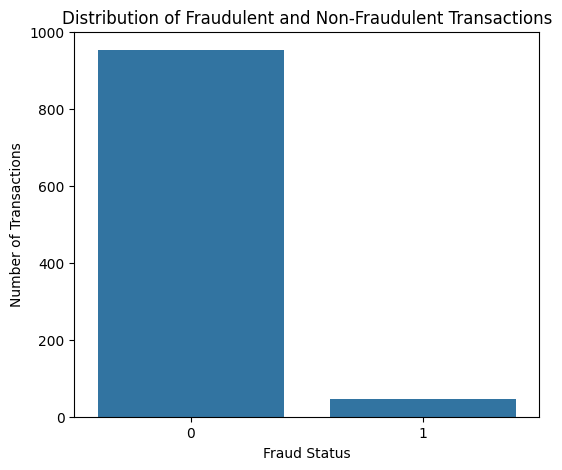

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(x="IsFraud",data=df)

plt.title("Distribution of Fraudulent and Non-Fraudulent Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Number of Transactions")

plt.show()

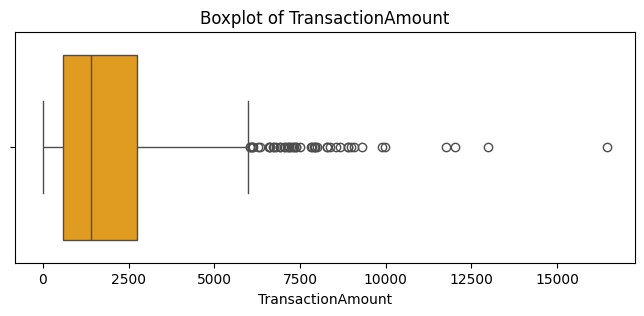

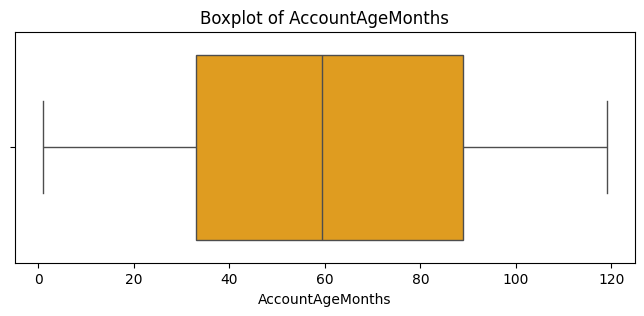

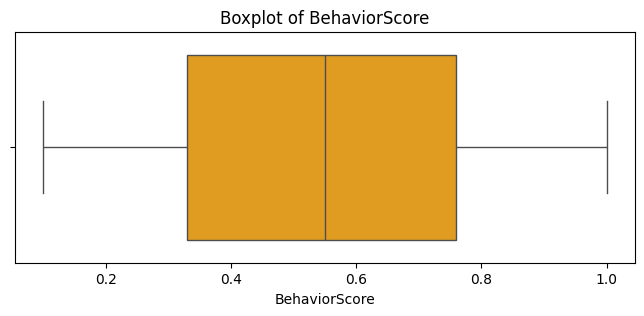

In [ ]:
for column in ['TransactionAmount', 'AccountAgeMonths', 'BehaviorScore']:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[column],color="orange")
    plt.title(f"Boxplot of {column}")
    plt.show()

In [ ]:
skewness = df[['TransactionAmount', 'AccountAgeMonths', 'BehaviorScore']].skew()

print("Skewness of Numerical Features:")
print(skewness)

Skewness of Numerical Features:
TransactionAmount    1.997469
AccountAgeMonths    -0.022760
BehaviorScore        0.003162
dtype: float64


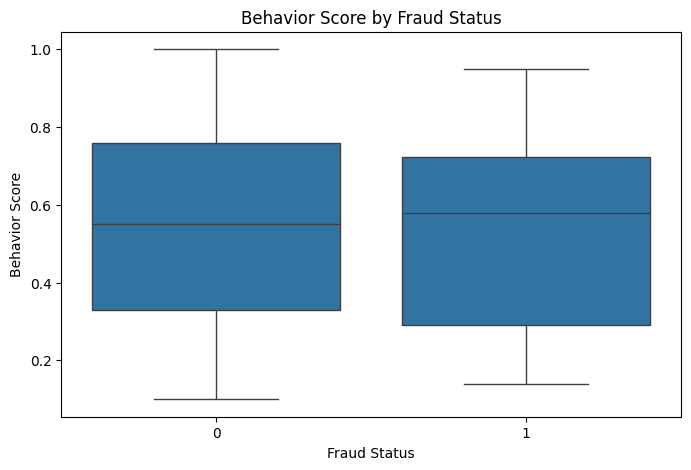

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,x="IsFraud",y="BehaviorScore")

plt.title("Behavior Score by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Behavior Score")

plt.show()

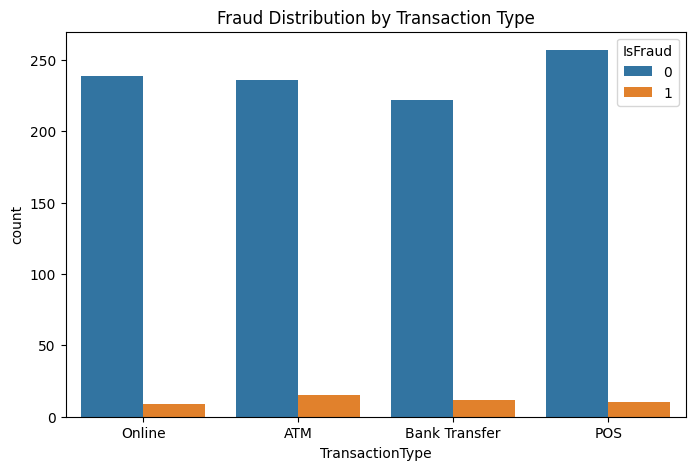

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="TransactionType",hue="IsFraud")

plt.title("Fraud Distribution by Transaction Type")

plt.show()

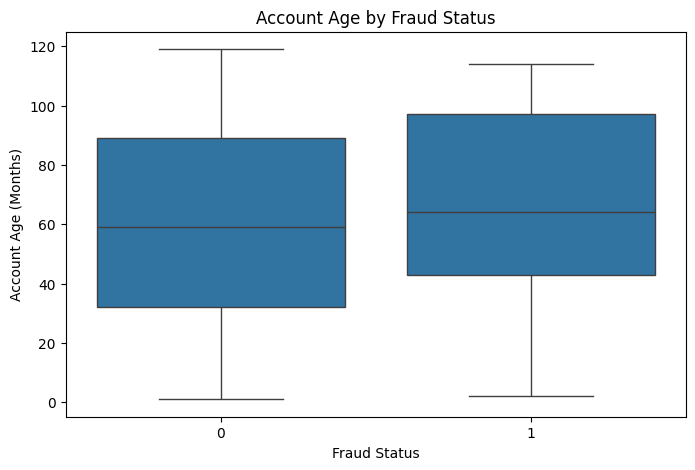

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,x="IsFraud",y="AccountAgeMonths")

plt.title("Account Age by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Account Age (Months)")

plt.show()

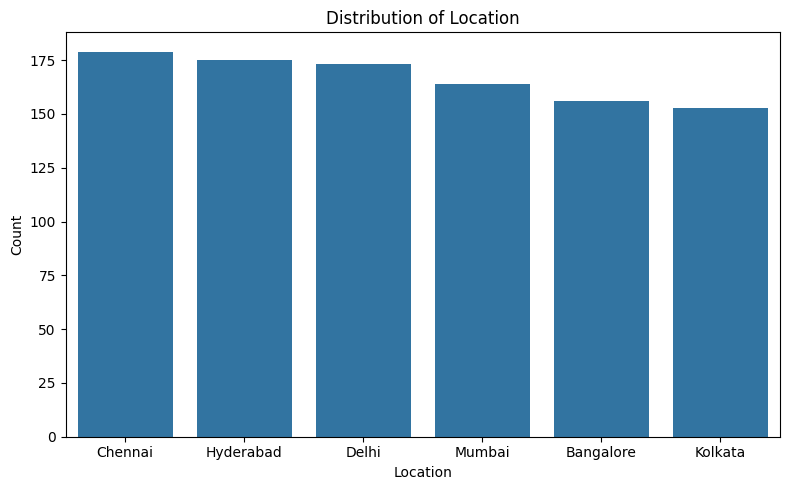

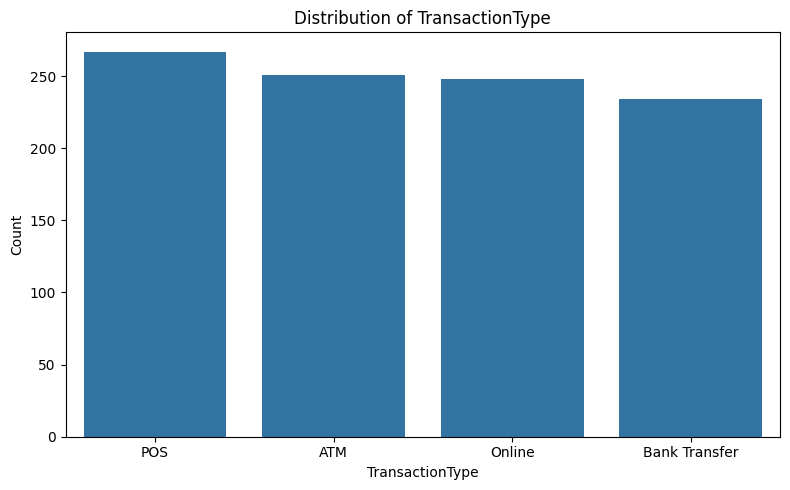

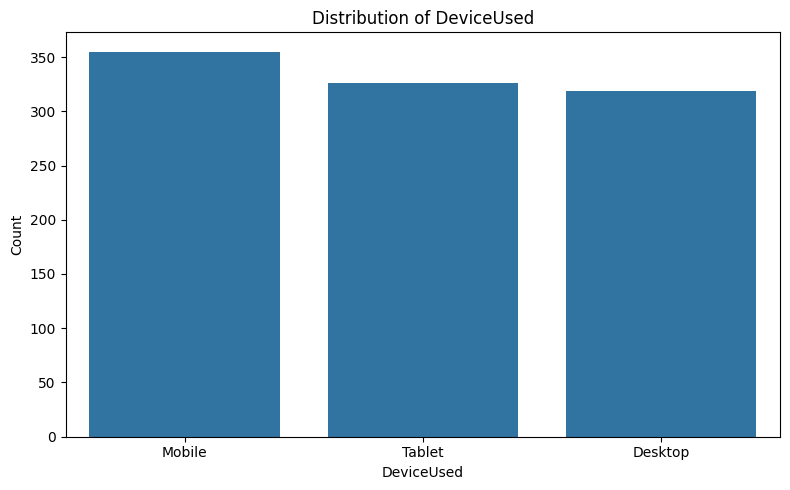

In [ ]:
for column in df[[ "Location","TransactionType","DeviceUsed"]]:

    plt.figure(figsize=(8,5))

    sns.countplot(data=df,x=column,order=df[column].value_counts().index)

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")



    plt.tight_layout()
    plt.show()

In [ ]:
correlation_matrix = df[["TransactionAmount","AccountAgeMonths","BehaviorScore","IsFraud"]].corr()

correlation_matrix

,TransactionAmount,AccountAgeMonths,BehaviorScore,IsFraud
TransactionAmount,1.000000,0.048485,-0.009049,-0.017650
AccountAgeMonths,0.048485,1.000000,0.003305,0.026762
BehaviorScore,-0.009049,0.003305,1.000000,-0.015140
IsFraud,-0.017650,0.026762,-0.015140,1.000000


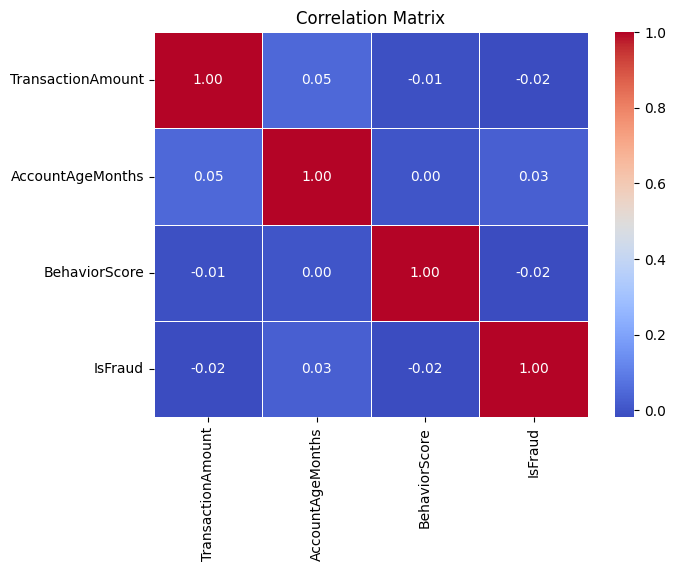

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

# **Data Preprocessing**

In [ ]:
df["TransactionTime"].head()

,TransactionTime
0,2023-01-01 13:27:00
1,2023-01-01 04:52:00
2,2023-01-01 13:17:00
3,2023-01-01 21:05:00
4,2023-01-01 03:29:00


In [ ]:
df["TransactionTime"] = pd.to_datetime(df["TransactionTime"])

df["TransactionHour"] = df["TransactionTime"].dt.hour

df[["TransactionTime", "TransactionHour"]].head()

,TransactionTime,TransactionHour
0,2023-01-01 13:27:00,13
1,2023-01-01 04:52:00,4
2,2023-01-01 13:17:00,13
3,2023-01-01 21:05:00,21
4,2023-01-01 03:29:00,3


In [ ]:
df.drop(columns=["CustomerID", "TransactionTime"],inplace=True)

In [ ]:
label_encoder = LabelEncoder()
for column in ['Location', 'TransactionType', 'DeviceUsed']:
    df[column] = label_encoder.fit_transform(df[column])
df.head()

,TransactionAmount,Location,TransactionType,AccountAgeMonths,BehaviorScore,DeviceUsed,IsFraud,TransactionHour
0,1834.26,0,2,89,0.10,1,0,13
1,3130.03,1,0,44,0.63,2,0,4
2,3030.78,1,1,97,0.62,2,1,13
3,493.04,2,3,13,0.24,1,0,21
4,1298.36,1,2,24,0.98,0,0,3


# **Define Target Variable (y) and Feature Variables (X)**

In [ ]:
df.columns

Index(['TransactionAmount', 'Location', 'TransactionType', 'AccountAgeMonths',
       'BehaviorScore', 'DeviceUsed', 'IsFraud', 'TransactionHour'],
      dtype='object')

In [ ]:
X = df[['TransactionAmount', 'Location', 'TransactionType', 'AccountAgeMonths',
       'BehaviorScore', 'DeviceUsed','TransactionHour']]

y = df['IsFraud']

# **Train Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2529,stratify=y,)

from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=2529)

X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

## **Modeling**

In [ ]:
model = RandomForestClassifier(random_state = 2529)

model.fit(X_train_smote,y_train_smote)
y_pred = model.predict(X_test)

# **Model Evaluation**

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f} \n Precision: {precision:.4f} \n Recall: {recall:.4f} \n F1 Score: {f1:.4f} \n ROC-AUC: {roc_auc:.4f}")


print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8600 
 Precision: 0.1200 
 Recall: 0.3333 
 F1 Score: 0.1765 
 ROC-AUC: 0.6091

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.88      0.92       191
           1       0.12      0.33      0.18         9

    accuracy                           0.86       200
   macro avg       0.54      0.61      0.55       200
weighted avg       0.93      0.86      0.89       200


Confusion Matrix

[[169  22]
 [  6   3]]


# **Prediction**

In [ ]:
predictions = model.predict(X_test)
prediction_df = pd.DataFrame({"Actual": y_test.values,"Predicted": predictions})
prediction_df.head()

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,1,1
4,0,0


# **Explaination**
This project focuses on detecting fraudulent banking transactions using machine learning. First, the dataset was imported and explored to understand its structure and identify the target variable. Exploratory Data Analysis (EDA) was performed using different visualizations to study the distribution of features and understand the relationship between transaction details and fraud. It was observed that the dataset was highly imbalanced, with very few fraudulent transactions compared to legitimate ones.

During preprocessing, the TransactionTime column was converted into a new feature called TransactionHour, while unnecessary columns such as CustomerID and the original timestamp were removed. Categorical features were encoded into numerical values using Label Encoding. The dataset was then split into training and testing sets using stratified sampling, and SMOTE was applied only to the training data to balance the classes. The features were standardized using StandardScaler.

Finally, a Random Forest Classifier was trained on the processed data. The model was evaluated using metrics such as Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, Classification Report, and Confusion Matrix. The trained model was then used to predict whether a transaction was fraudulent or legitimate, demonstrating how machine learning can be used to improve fraud detection in banking systems.